In [1]:
pip install python-louvain networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt

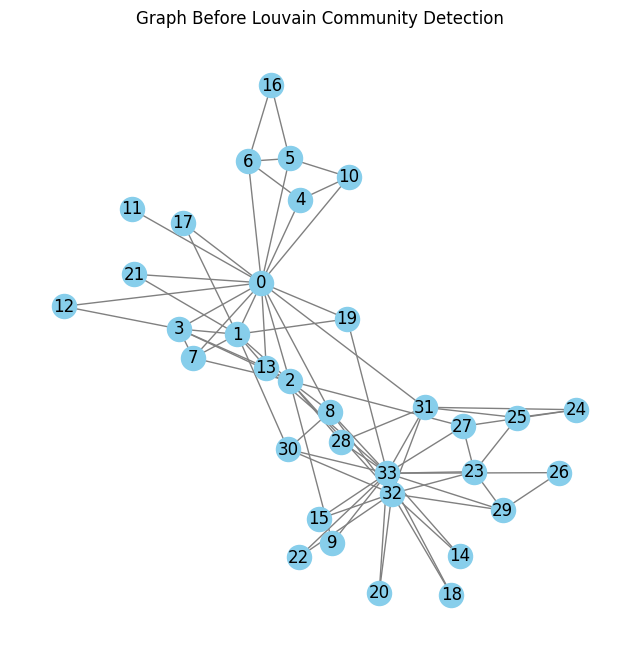

In [4]:
# Build a sample graph
G = nx.karate_club_graph()

# Plot the graph before Louvain partitioning
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_color="skyblue",
    node_size=300,
    with_labels=True,
    edge_color="gray"
)

plt.title("Graph Before Louvain Community Detection")
plt.axis("off")
plt.show()

Community 2: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
Community 0: [1, 2, 3, 7, 12, 13]
Community 3: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
Community 1: [24, 25, 28, 31]
Modularity: 0.42662243960945256


C:\Users\adwai\AppData\Local\Temp\ipykernel_16752\747563847.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


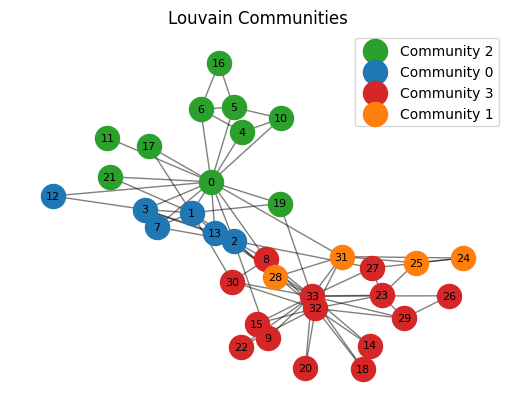

In [11]:
# Run Louvain community detection
partition = community_louvain.best_partition(G)

# Print nodes grouped by community
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

for comm_id, nodes in communities.items():
    print(f"Community {comm_id}: {nodes}")

# Compute modularity score
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

# Visualize communities
pos = nx.spring_layout(G, seed=42)
cmap = plt.cm.get_cmap("tab10")

for comm_id, nodes in communities.items():
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodes,
        node_color=[cmap(comm_id)],
        node_size=300,
        label=f"Community {comm_id}"
    )

nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Louvain Communities")
plt.axis("off")
plt.legend()
plt.show()